**INTRODUCTION**

This Notebook contains analysis of Top 50 Spotify Tracks 2020 dataset (https://www.kaggle.com/datasets/atillacolak/top-50-spotify-tracks-2020).
The task it to load the data using Pandas, perform data cleaning and exploratory data analysis.

Import libraries and load the data. Since the data set is only 50 records, I want to see and explore full data:

In [1]:
import pandas as pd
from pathlib import Path

In [2]:
# Point to the folder (raw string avoids backslash escapes)
data_dir = Path(r"C:\Users\Viktorija\PycharmProjects\PythonProject\Spotify project\Data")
csv_path = data_dir / "spotifytoptracks.csv"
df = pd.read_csv(csv_path, encoding="utf-8")

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

df

,Unnamed: 0,artist,album,track_name,track_id,energy,danceability,key,loudness,acousticness,speechiness,instrumentalness,liveness,valence,tempo,duration_ms,genre
0,0,The Weeknd,After Hours,Blinding Lights,0VjIjW4GlUZAMYd2vXMi3b,0.730,0.514,1,-5.934,0.00146,0.0598,0.000095,0.0897,0.3340,171.005,200040,R&B/Soul
1,1,Tones And I,Dance Monkey,Dance Monkey,1rgnBhdG2JDFTbYkYRZAku,0.593,0.825,6,-6.401,0.68800,0.0988,0.000161,0.1700,0.5400,98.078,209755,Alternative/Indie
2,2,Roddy Ricch,Please Excuse Me For Being Antisocial,The Box,0nbXyq5TXYPCO7pr3N8S4I,0.586,0.896,10,-6.687,0.10400,0.0559,0.000000,0.7900,0.6420,116.971,196653,Hip-Hop/Rap
3,3,SAINt JHN,Roses (Imanbek Remix),Roses - Imanbek Remix,2Wo6QQD1KMDWeFkkjLqwx5,0.721,0.785,8,-5.457,0.01490,0.0506,0.004320,0.2850,0.8940,121.962,176219,Dance/Electronic
4,4,Dua Lipa,Future Nostalgia,Don't Start Now,3PfIrDoz19wz7qK7tYeu62,0.793,0.793,11,-4.521,0.01230,0.0830,0.000000,0.0951,0.6790,123.950,183290,Nu-disco
5,5,DaBaby,BLAME IT ON BABY,ROCKSTAR (feat. Roddy Ricch),7ytR5pFWmSjzHJIeQkgog4,0.690,0.746,11,-7.956,0.24700,0.1640,0.000000,0.1010,0.4970,89.977,181733,Hip-Hop/Rap
6,6,Harry Styles,Fine Line,Watermelon Sugar,6UelLqGlWMcVH1E5c4H7lY,0.816,0.548,0,-4.209,0.12200,0.0465,0.000000,0.3350,0.5570,95.390,174000,Pop
7,7,Powfu,death bed (coffee for your head),death bed (coffee for your head),7eJMfftS33KTjuF7lTsMCx,0.431,0.726,8,-8.765,0.73100,0.1350,0.000000,0.6960,0.3480,144.026,173333,Hip-Hop/Rap
8,8,Trevor Daniel,Nicotine,Falling,2rRJrJEo19S2J82BDsQ3F7,0.430,0.784,10,-8.756,0.12300,0.0364,0.000000,0.0887,0.2360,127.087,159382,R&B/Hip-Hop alternative
9,9,Lewis Capaldi,Divinely Uninspired To A Hellish Extent,Someone You Loved,7qEHsqek33rTcFNT9PFqLf,0.405,0.501,1,-5.679,0.75100,0.0319,0.000000,0.1050,0.4460,109.891,182161,Alternative/Indie


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        50 non-null     int64  
 1   artist            50 non-null     object 
 2   album             50 non-null     object 
 3   track_name        50 non-null     object 
 4   track_id          50 non-null     object 
 5   energy            50 non-null     float64
 6   danceability      50 non-null     float64
 7   key               50 non-null     int64  
 8   loudness          50 non-null     float64
 9   acousticness      50 non-null     float64
 10  speechiness       50 non-null     float64
 11  instrumentalness  50 non-null     float64
 12  liveness          50 non-null     float64
 13  valence           50 non-null     float64
 14  tempo             50 non-null     float64
 15  duration_ms       50 non-null     int64  
 16  genre             50 non-null     object 
dtyp

**DATA CLEANING**

Handling missing values:

Let's see if there are any missing values. In the output we expect a value to be False if there are no null values.


In [3]:
print("***Missing values per column ***")
df.isnull().any().sum()


***Missing values per column ***


np.int64(0)

Removing duplicates:

Let's check if there are any duplicates. In the output I expect a value to be False if there are no duplicated rows. I check artist and track name because these are the duplicates that would matter.

In [7]:
print("***Total duplicate rows***")
df.duplicated(subset=["artist", "track_name"]).sum()

***Total duplicate rows***


np.int64(0)

Treating outliers:

Let's check if there are any outliers. False would mean there are no outliers, true - is outlier.

In [9]:
# compute 1.5*IQR bounds per column + boolean flags
num_cols = df.select_dtypes(include="number").columns.difference(["Unnamed: 0"])
for col in num_cols:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    df[f"is_outlier_{col}"] = (df[col] < lower) | (df[col] > upper)

flag_cols = [c for c in df.columns if c.startswith("is_outlier_")]
df_out = df[df[flag_cols].any(axis=1)]
df_out


,Unnamed: 0,artist,album,track_name,track_id,energy,danceability,key,loudness,acousticness,speechiness,instrumentalness,liveness,valence,tempo,duration_ms,genre,is_outlier_acousticness,is_outlier_danceability,is_outlier_duration_ms,is_outlier_energy,is_outlier_instrumentalness,is_outlier_key,is_outlier_liveness,is_outlier_loudness,is_outlier_speechiness,is_outlier_tempo,is_outlier_valence
0,0,The Weeknd,After Hours,Blinding Lights,0VjIjW4GlUZAMYd2vXMi3b,0.730,0.514,1,-5.934,0.00146,0.0598,0.000095,0.0897,0.334,171.005,200040,R&B/Soul,False,False,False,False,True,False,False,False,False,False,False
1,1,Tones And I,Dance Monkey,Dance Monkey,1rgnBhdG2JDFTbYkYRZAku,0.593,0.825,6,-6.401,0.68800,0.0988,0.000161,0.1700,0.540,98.078,209755,Alternative/Indie,True,False,False,False,True,False,False,False,False,False,False
2,2,Roddy Ricch,Please Excuse Me For Being Antisocial,The Box,0nbXyq5TXYPCO7pr3N8S4I,0.586,0.896,10,-6.687,0.10400,0.0559,0.000000,0.7900,0.642,116.971,196653,Hip-Hop/Rap,False,False,False,False,False,False,True,False,False,False,False
3,3,SAINt JHN,Roses (Imanbek Remix),Roses - Imanbek Remix,2Wo6QQD1KMDWeFkkjLqwx5,0.721,0.785,8,-5.457,0.01490,0.0506,0.004320,0.2850,0.894,121.962,176219,Dance/Electronic,False,False,False,False,True,False,False,False,False,False,False
7,7,Powfu,death bed (coffee for your head),death bed (coffee for your head),7eJMfftS33KTjuF7lTsMCx,0.431,0.726,8,-8.765,0.73100,0.1350,0.000000,0.6960,0.348,144.026,173333,Hip-Hop/Rap,True,False,False,False,False,False,True,False,False,False,False
9,9,Lewis Capaldi,Divinely Uninspired To A Hellish Extent,Someone You Loved,7qEHsqek33rTcFNT9PFqLf,0.405,0.501,1,-5.679,0.75100,0.0319,0.000000,0.1050,0.446,109.891,182161,Alternative/Indie,True,False,False,False,False,False,False,False,False,False,False
10,10,KAROL G,Tusa,Tusa,7k4t7uLgtOxPwTpFmtJNTY,0.715,0.803,2,-3.280,0.29500,0.2980,0.000134,0.0574,0.574,101.085,200960,Pop,False,False,False,False,True,False,False,False,False,False,False
12,12,Post Malone,Hollywood's Bleeding,Circles,21jGcNKet2qwijlDFuPiPb,0.762,0.695,0,-3.497,0.19200,0.0395,0.002440,0.0863,0.553,120.042,215280,Pop/Soft Rock,False,False,False,False,True,False,False,False,False,False,False
16,16,Lewis Capaldi,Divinely Uninspired To A Hellish Extent (Extended Edition),Before You Go,2gMXnyrvIjhVBUZwvLZDMP,0.575,0.459,3,-4.858,0.60400,0.0573,0.000000,0.0885,0.183,111.881,215107,Alternative/Indie,False,True,False,False,False,False,False,False,False,False,False
18,18,Maroon 5,Memories,Memories,2b8fOow8UzyDFAE27YhOZM,0.320,0.764,11,-7.209,0.83700,0.0546,0.000000,0.0822,0.575,91.019,189486,Pop,True,False,False,False,False,False,False,False,False,False,False


**EXPLORATORY DATA ANALYSIS**

How many observations are there in this dataset?

In the below cell we are counting row numbers as observations.

In [23]:
print(f"Rows: {len(df)}")

Rows: 50


How many features are the in the dataset? Which of the features are categorical and numerical?

In the below cell I am counting row numbers of index as observations and column numbers as features.

In [24]:
dfn = df.drop(columns=df.filter(regex=r'^is_outlier_').columns, errors='ignore') \
        .drop(columns=['Unnamed: 0'], errors='ignore')

num_cols = dfn.select_dtypes(include='number').columns.tolist()
cat_cols = dfn.select_dtypes(include=['object','category','string']).columns.tolist()

print(f"Numeric ({len(num_cols)}): {num_cols}")
print(f"Categorical ({len(cat_cols)}): {cat_cols}")
print(f"Total columns: {len(dfn.columns)}")


Numeric (11): ['energy', 'danceability', 'key', 'loudness', 'acousticness', 'speechiness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']
Categorical (5): ['artist', 'album', 'track_name', 'track_id', 'genre']
Total columns: 16


Are there any artists that have more than 1 popular track? If yes, which, and how many?

I count all the artists and if they appear more than once they are on the list. If there are no artist that has more than 1 track then it should print the message: "No artist has more than 1 track".

In [25]:
all_artists = df['artist'].value_counts()
popular_artists = all_artists[all_artists > 1]

if popular_artists.empty:
    print("No artist has more than 1 track")
else:
    print(popular_artists.sort_values(ascending=False))

artist
Dua Lipa         3
Billie Eilish    3
Travis Scott     3
Harry Styles     2
Lewis Capaldi    2
Justin Bieber    2
Post Malone      2
Name: count, dtype: int64


Who was the most popular artist?

I am using max() function to check which artist appeared on the list max amount of times.

In [26]:
max_songs_by_artist = popular_artists.max()
most_popular_artists = popular_artists[(popular_artists == max_songs_by_artist)]
print (most_popular_artists)

artist
Dua Lipa         3
Billie Eilish    3
Travis Scott     3
Name: count, dtype: int64


How many artists have their songs in the top 50 in total?

I am counting all the unique artists.

In [128]:
print (all_artists.count())

40


Are there any albums that have more than 1 popular track? If yes, which, and how many?

I check how many times albums show up on the list and print the ones that showed up most.

In [27]:
albums_with_tracks = df.groupby('album')['track_name'].count().sort_values(ascending=False)
min_albums_with_songs = albums_with_tracks.min()
most_popular_albums = albums_with_tracks[(albums_with_tracks > 1)]
most_popular_albums

album
Future Nostalgia        3
Fine Line               2
Hollywood's Bleeding    2
Changes                 2
Name: track_name, dtype: int64

How many albums in total have their songs in the top 50?

I check the unique albums.

In [28]:
print (albums_with_tracks.count())

45


Which tracks have danceability score above 0,7?

In [29]:
df_sorted_by_danceability = df.sort_values('danceability', ascending = False)
high_danceability = df_sorted_by_danceability[(df_sorted_by_danceability['danceability'] > 0.7)]
print (high_danceability[['track_name', 'danceability']])

                                       track_name  danceability
27                WAP (feat. Megan Thee Stallion)         0.935
2                                         The Box         0.896
39                                        Ride It         0.880
28                                    Sunday Best         0.878
33               Supalonely (feat. Gus Dapperton)         0.862
40                                     goosebumps         0.841
49                                     SICKO MODE         0.834
15                                   Toosie Slide         0.830
1                                    Dance Monkey         0.825
29                    Godzilla (feat. Juice WRLD)         0.808
14                       Intentions (feat. Quavo)         0.806
10                                           Tusa         0.803
19                     Life Is Good (feat. Drake)         0.795
4                                 Don't Start Now         0.793
22                                    Br

In [30]:
mask = df["danceability"] > 0.7
pct_all = mask.mean() * 100  # % of all rows

print(f"{pct_all:.1f}% of all songs have danceability > 0.7")

64.0% of all songs have danceability > 0.7


Which tracks have a danceability score below 0.4?

In [131]:
low_danceability = df_sorted_by_danceability[(df_sorted_by_danceability['danceability'] < 0.4)]
print (low_danceability[['track_name', 'danceability']])

              track_name  danceability
44  lovely (with Khalid)         0.351


In [31]:
mask = df["danceability"] < 0.4
pct_below_04 = mask.mean() * 100

print(f"{pct_below_04:.1f}% of all songs have danceability < 0.4")

2.0% of all songs have danceability < 0.4


Which tracks have their loudness above -5?

In [32]:
df_sorted_by_loudness = df.sort_values('loudness', ascending = False)
high_loudness = df_sorted_by_loudness[(df_sorted_by_loudness['loudness'] > -5.)]
print (high_loudness[['track_name', 'loudness']])

                                       track_name  loudness
10                                           Tusa    -3.280
40                                     goosebumps    -3.370
31                                 Break My Heart    -3.434
38                                          Hawái    -3.454
12                                        Circles    -3.497
23                         Mood (feat. iann dior)    -3.558
21                                      Adore You    -3.675
49                                     SICKO MODE    -3.714
48                                       Physical    -3.756
35                Rain On Me (with Ariana Grande)    -3.764
43                                        Safaera    -4.074
6                                Watermelon Sugar    -4.209
39                                        Ride It    -4.258
37  Sunflower - Spider-Man: Into the Spider-Verse    -4.368
32                                       Dynamite    -4.410
4                                 Don't 

In [33]:
mask = df["loudness"] > -5
pct_above_minus5 = mask.mean() * 100

print(f"{pct_above_minus5:.1f}% of all songs have loudness > -5")

38.0% of all songs have loudness > -5


Which tracks have their loudness below -8?

In [34]:
low_loudness = df_sorted_by_loudness[(df_sorted_by_loudness['loudness'] < -8.)]
print (low_loudness[['track_name', 'loudness']])

                                        track_name  loudness
20                Savage Love (Laxed - Siren Beat)    -8.520
8                                          Falling    -8.756
36                             HIGHEST IN THE ROOM    -8.764
7                 death bed (coffee for your head)    -8.765
15                                    Toosie Slide    -8.820
47  If the World Was Ending - feat. Julia Michaels   -10.086
44                            lovely (with Khalid)   -10.109
26                                         bad guy   -10.965
24                             everything i wanted   -14.454


In [35]:
mask = df["loudness"] < -8
pct_below_minus8 = mask.mean() * 100

print(f"{pct_below_minus8:.1f}% of all songs have loudness < -8")

18.0% of all songs have loudness < -8


Which track is the longest?

In [39]:
s = df.groupby("track_name")["duration_ms"].max()

name = s.idxmax()
ms = s.loc[name]

minutes = ms / 60000
total_sec = round(ms / 1000)
m, ssec = divmod(total_sec, 60)

print(f"Longest track: {name}")
print(f"Duration: {minutes:.2f} minutes ({m}:{ssec:02d})")

Longest track: SICKO MODE
Duration: 5.21 minutes (5:13)


Which track is the shortest?

In [40]:
s = df.groupby("track_name")["duration_ms"].max()

name = s.idxmin()
ms = s.loc[name]

minutes = ms / 60000
total_sec = round(ms / 1000)
m, ssec = divmod(total_sec, 60)

print(f"Shortest track: {name}")
print(f"Duration: {minutes:.2f} minutes ({m}:{ssec:02d})")

Shortest track: Mood (feat. iann dior)
Duration: 2.34 minutes (2:21)


Which genre is the most popular?

In [41]:
df['genre'].value_counts().head(1)

genre
Pop    14
Name: count, dtype: int64

Which genres have just one song in the top 50?

In [141]:
genre = df.groupby('genre')['track_name'].aggregate('count').sort_values(ascending=False)
least_popular_genre = genre[(genre[:] < 2)]
print (least_popular_genre)

genre
Chamber pop                           1
Alternative/reggaeton/experimental    1
Dreampop/Hip-Hop/R&B                  1
Disco-pop                             1
Dance-pop/Disco                       1
Hip-Hop/Trap                          1
Nu-disco                              1
Pop rap                               1
Pop/Soft Rock                         1
R&B/Hip-Hop alternative               1
Name: track_name, dtype: int64


How many genres in total are represented in the top 50?

In [42]:
df['genre'].nunique()

16

Which features are strongly positively correlated?


In [76]:
POS_STRONG = 0.70  # r ≥ 0.70

# Remove rows with any outlier flag True and drop the flag columns
flag_cols = [c for c in df.columns if c.startswith("is_outlier_")]
if flag_cols:
    df_clean = df.loc[~df[flag_cols].any(axis=1)].drop(columns=flag_cols).copy()
else:
    df_clean = df.copy()

# Keep numeric  features only
num = df_clean.select_dtypes(include="number")
num = num[[c for c in num.columns if num[c].dtype != bool]]

# Correlation matrix
corr = num.corr(method="pearson")

# Unique pairs only
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
pairs = corr.where(mask).stack().reset_index()
pairs.columns = ["feature_1", "feature_2", "correlation"]

# Strongly positive only
positive_corr = pairs[pairs["correlation"] >= POS_STRONG] \
                    .sort_values("correlation", ascending=False)

print("Strongly POSITIVE correlations ( ≥ {:.2f})".format(POS_STRONG))
print(positive_corr.to_string(index=False) if not positive_corr.empty else "None")

Strongly POSITIVE correlations ( ≥ 0.70)
feature_1 feature_2  correlation
   energy  loudness     0.796617


Which features are strongly negatively correlated?

In [77]:
NEG_STRONG = 0.70  # r ≤ -0.70

# Remove rows with any outlier flag True and drop the flag columns
flag_cols = [c for c in df.columns if c.startswith("is_outlier_")]
if flag_cols:
    df_clean = df.loc[~df[flag_cols].any(axis=1)].drop(columns=flag_cols).copy()
else:
    df_clean = df.copy()

#Keep numeric features only
num = df_clean.select_dtypes(include="number")
num = num[[c for c in num.columns if num[c].dtype != bool]]

# Correlation matrix
corr = num.corr(method="pearson")

#Unique pairs only
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
pairs = corr.where(mask).stack().reset_index()
pairs.columns = ["feature_1", "feature_2", "correlation"]

#Strongly negative only
negative_corr = pairs[pairs["correlation"] <= -NEG_STRONG] \
                    .sort_values("correlation", ascending=True)

print("Strongly NEGATIVE correlations ( ≤ -{:.2f})".format(NEG_STRONG))
print(negative_corr.to_string(index=False) if not negative_corr.empty else "None")

Strongly NEGATIVE correlations ( ≤ -0.70)
   feature_1 feature_2  correlation
danceability  liveness    -0.704876


Which features are not correlated?

In [78]:
NO_CORR = 0.30   # |r| < 0.30 → not correlated

# Remove rows with any outlier flag True and drop the flag columns
flag_cols = [c for c in df.columns if c.startswith("is_outlier_")]
if flag_cols:
    df_clean = df.loc[~df[flag_cols].any(axis=1)].drop(columns=flag_cols).copy()
else:
    df_clean = df.copy()

#Keep numeric  features only
num = df_clean.select_dtypes(include="number")
num = num[[c for c in num.columns if num[c].dtype != bool]]

# Correlation matrix
corr = num.corr(method="pearson")

# Unique pairs only
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
pairs = corr.where(mask).stack().reset_index()
pairs.columns = ["feature_1", "feature_2", "correlation"]

# Not correlated only
not_corr = pairs[pairs["correlation"].abs() < NO_CORR] \
               .sort_values(by="correlation", key=lambda s: s.abs())

print("Not correlated pairs ( < {:.2f})".format(NO_CORR))
print(not_corr.to_string(index=False) if not not_corr.empty else "None")

Not correlated pairs ( < 0.30)
       feature_1        feature_2  correlation
        loudness instrumentalness    -0.001264
      Unnamed: 0 instrumentalness     0.002242
          energy instrumentalness    -0.012617
     speechiness instrumentalness     0.014836
             key          valence     0.016082
        loudness            tempo    -0.016840
    danceability      speechiness     0.017574
     speechiness         liveness     0.024899
        liveness      duration_ms     0.028651
          energy      duration_ms     0.028672
    danceability      duration_ms    -0.035103
         valence      duration_ms     0.037308
          energy     danceability    -0.040449
    acousticness            tempo    -0.040685
    danceability         loudness    -0.041115
    danceability     acousticness     0.051417
    danceability              key     0.064576
          energy      speechiness     0.064791
             key      speechiness     0.077552
    acousticness      duratio

How does the danceability, loudness and acoustics scores compare between Pop, Hip-Hop/Rap, Dance/Electronic, and Alternative/Indie genres?

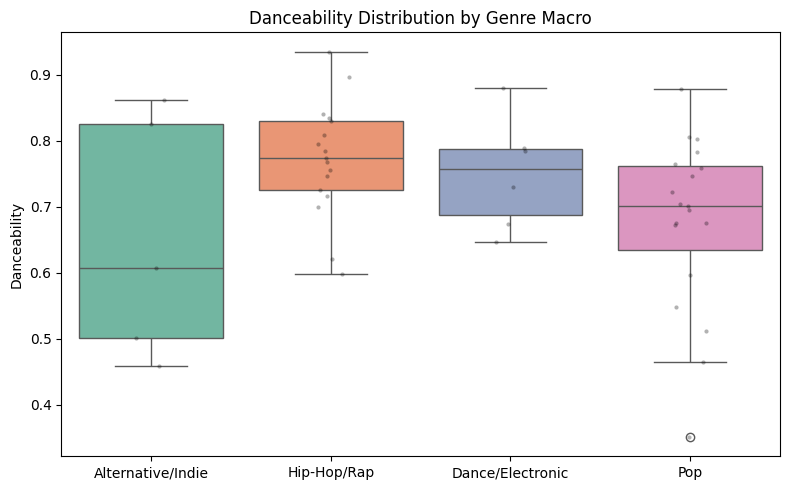

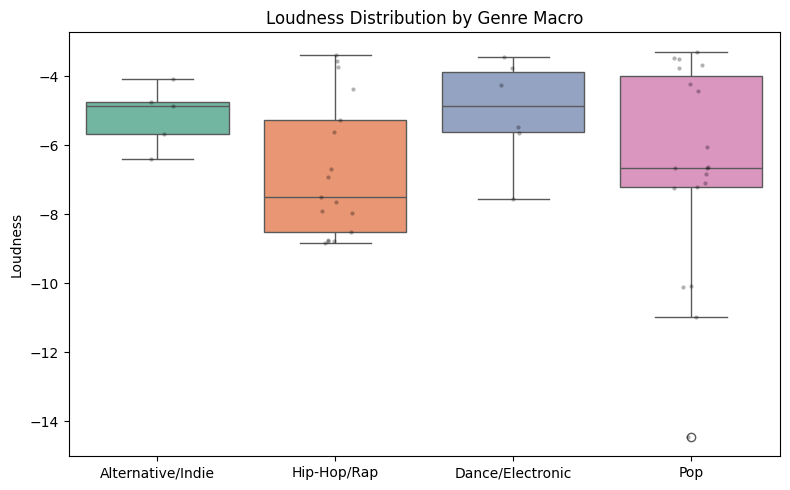

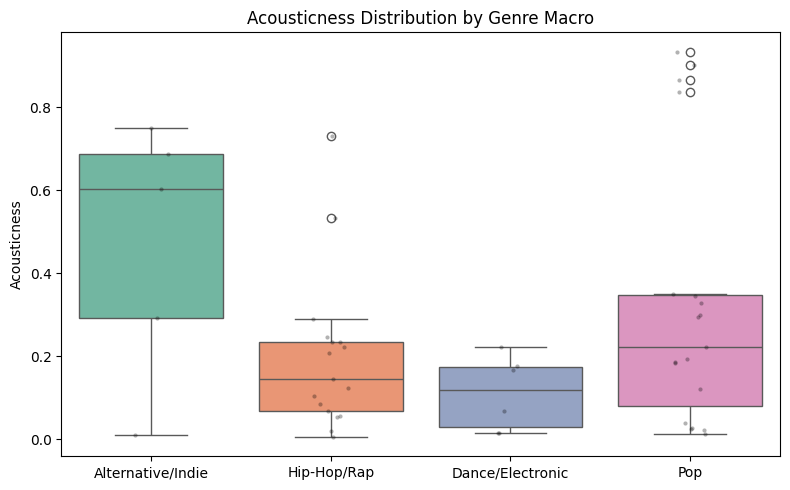

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

if "genre" in df.columns:
    def macro(g):
        s = str(g).lower()
        if "hip" in s or "rap" in s: return "Hip-Hop/Rap"
        if any(x in s for x in ["dance", "edm", "electronic", "house"]): return "Dance/Electronic"
        if any(x in s for x in ["indie", "alternative"]): return "Alternative/Indie"
        if "pop" in s: return "Pop"
        return None

    df["genre_macro"] = df["genre"].map(macro)
    focus = df[df["genre_macro"].isin(["Pop", "Hip-Hop/Rap", "Dance/Electronic", "Alternative/Indie"])]

    if not focus.empty:
        for feature in ["danceability", "loudness", "acousticness"]:
            if feature in focus.columns:
                plt.figure(figsize=(8, 5))
                sns.boxplot(
                    data=focus,
                    x="genre_macro",
                    y=feature,
                    hue="genre_macro",   # 👈 assign hue same as x
                    palette="Set2",
                    legend=False
                )
                sns.stripplot(
                    data=focus,
                    x="genre_macro",
                    y=feature,
                    color="black",
                    alpha=0.3,
                    size=3
                )
                plt.title(f"{feature.capitalize()} Distribution by Genre Macro")
                plt.xlabel("")
                plt.ylabel(feature.capitalize())
                plt.tight_layout()
                plt.show()
            else:
                print(f"Column '{feature}' missing.")
    else:
        print("No rows found for selected genres.")
else:
    print("Column 'genre' not found.")

Danceability:

Hip-Hop/Rap and Dance/Electronic songs are the most danceable.
Pop songs are a bit less danceable.
Alternative/Indie songs vary a lot — some are danceable, some are not.

Loudness:

Dance/Electronic songs are the loudest.
Alternative/Indie songs are a bit quieter.
Pop and Hip-Hop/Rap songs have more variety — some are loud, others softer.

Acousticness:

Alternative/Indie songs are the most acoustic (use more real instruments).
Pop, Hip-Hop/Rap, and Dance/Electronic are mostly electronic.

IMPROVEMENTS

1. Include data visualization.
2. Handle the outliers.
3. Check following years to see trends.

CONCLUSIONS

3 artists have more than one track in the list.

1 album has 3 songs, and 3 albums have 2 songs on the list.

64% of songs are highly danceable and only 2% are low.

38% of songs are loud (> -5 dB), and 18% are quiet (< -8 dB).

Pop is the most common genre, with 16 songs total.

Energy and Loudness are strongly positively correlated.

Danceability and Liveness are strongly negatively correlated.

Dance/Electronic and Hip-Hop/Rap are the most danceable and loudest.

Pop songs are balanced.

Alternative/Indie songs are softer and more acoustic.


